# INSID3-Instance — step-by-step walkthrough

Training-free **intra-image instance suggestion** from frozen DINOv3 features.

This notebook runs the pipeline in `models/insid3/` **one stage at a time** on a real
coral image, visualizing the intermediate of each stage so you can see exactly what
every step contributes.

**Why the old `WatershedDINO` was flawed:** it watershedded the *class*-similarity map.
But DINOv3 features are instance-*invariant* — every coral fragment looks alike in feature
space — so that map has no per-instance structure. Watershed on it just floods noise peaks.

**The fix (this pipeline):**
1. **Features** — DINOv3 dense patch grid, L2-normalized.
2. **Gate** — exemplar similarity used *only* to decide *which patches are the class*.
3. **Clustering** — agglomerative over-segmentation into feature-coherent atoms.
4. **Individuation** — *marker-controlled* watershed on a **boundary** elevation (feature
   discontinuity + geometric distance) — the corrected watershed.
5. **Merge** — re-join over-split parts by intra-image self-similarity.

> Requires the gated DINOv3 weights: set `HF_ACCESS_TOKEN` (the service `.env` already
> carries it) and have accepted the model terms on the HuggingFace Hub.

## 0 · Setup

In [1]:
import os, sys, json
from pathlib import Path

# Run from the instance-discovery-service root so `models` imports resolve.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110

def show(*panels, cols=None, figsize=None):
    """panels: list of (title, image, kwargs)."""
    n = len(panels); cols = cols or n; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize or (4.2 * cols, 4.0 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (title, img, kw) in zip(axes, panels):
        ax.imshow(img, **kw); ax.set_title(title, fontsize=10); ax.axis("off")
    for ax in axes[len(panels):]: ax.axis("off")
    plt.tight_layout(); plt.show()

def label_cmap(n):
    """Random distinct colors for label maps; 0 -> black."""
    rng = np.random.default_rng(7)
    colors = rng.random((max(n, 1) + 1, 3)); colors[0] = 0
    return ListedColormap(colors)

def overlay_labels(image, labels, alpha=0.55):
    cmap = label_cmap(int(labels.max()))
    colored = cmap(labels / max(labels.max(), 1))[..., :3]
    out = image.astype(float) / 255.0
    m = labels > 0
    out[m] = (1 - alpha) * out[m] + alpha * colored[m]
    return out

## 1 · Load a coral image and an exemplar mask

We pull one real *Coral Fragment* annotation from the dataset COCO file to use as the in-context exemplar. Everything else in the image is what we want the model to discover.

image 20220309T1430_CBASS_US_Thatch_Ofav_32.5_T1_10-13.JPG  4000x3000  |  4 coral fragments


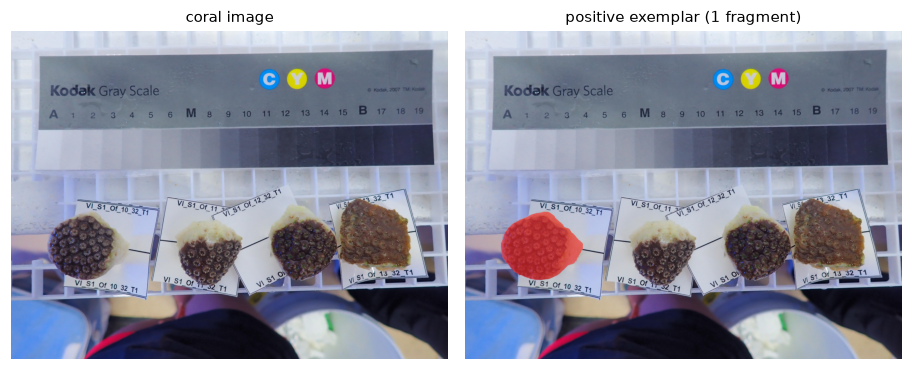

In [2]:
from pycocotools import mask as mask_utils
import cv2

DATA = ROOT.parent / "backend" / "data" / "datasets" / "Global Search Dataset"
coco = json.load(open(DATA / "Global_Search_Dataset_coco.json"))

# Use the image with the most annotations.
from collections import Counter
img_id = Counter(a["image_id"] for a in coco["annotations"]).most_common(1)[0][0]
img_meta = next(im for im in coco["images"] if im["id"] == img_id)

image = cv2.cvtColor(cv2.imread(str(DATA / "images" / img_meta["file_name"])), cv2.COLOR_BGR2RGB)
H, W = image.shape[:2]
# COCO canvas may differ from the stored image resolution -> scale polygons.
sx, sy = W / img_meta["width"], H / img_meta["height"]

CORAL = next(c["id"] for c in coco["categories"] if c["name"] == "Coral Fragment")
anns = [a for a in coco["annotations"] if a["image_id"] == img_id and a["category_id"] == CORAL]

def poly_to_mask(ann):
    m = np.zeros((H, W), np.uint8)
    for poly in ann["segmentation"]:
        pts = np.array(poly, float).reshape(-1, 2)
        pts[:, 0] *= sx; pts[:, 1] *= sy
        cv2.fillPoly(m, [pts.astype(np.int32)], 1)
    return m

gt_masks = [poly_to_mask(a) for a in anns]
gt_masks = [m for m in gt_masks if m.sum() > 0]
print(f"image {img_meta['file_name']}  {W}x{H}  |  {len(gt_masks)} coral fragments")

# Pick one fragment as the positive exemplar (here: a mid-sized one).
areas = [m.sum() for m in gt_masks]
exemplar_idx = int(np.argsort(areas)[len(areas) // 2])
positive_masks = [gt_masks[exemplar_idx]]
negative_masks = None  # optionally add background exemplars here

ov = image.copy()
ov[positive_masks[0] > 0] = (0.4 * ov[positive_masks[0] > 0] + 0.6 * np.array([255, 40, 40])).astype(np.uint8)
show(("coral image", image, {}), ("positive exemplar (1 fragment)", ov, {}))

## 2 · Backbone + run the whole pipeline once

`pipeline.run` threads all stages and returns **every** intermediate in an `InSID3Result`. We load the real DINOv3 backbone here; the cells below then dissect each stage from the result.

In [3]:
from iquana_toolbox.ai.backbones.dinov3 import DINOv3Backbone, DEFAULT_DINOV3_MODEL
from models.insid3 import pipeline, features as featlib, gate as gatelib, clustering, individuation, merge

backbone = DINOv3Backbone(model_id=DEFAULT_DINOV3_MODEL, image_size=1024, token=os.getenv("HF_ACCESS_TOKEN"))

params = pipeline.InSID3Params(
    gate_threshold=0.55,
    cluster_tau=0.18,
    marker_mode="hybrid",
    elevation_alpha=1.0,
    elevation_beta=0.5,
    merge_similarity=0.6,
    merge_boundary=0.5,
)
result = pipeline.run(backbone, image, positive_masks, negative_masks, params)
result.stats

C:\Users\role01-admin\PycharmProjects\iquana\instance-discovery-service\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 211/211 [00:00<00:00, 6798.42it/s]
C:\Users\role01-admin\PycharmProjects\iquana\instance-discovery-service\.venv\Lib\site-packages\sklearn\cluster\_agglomerative.py:595: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


{'n_atoms': 88,
 'n_watershed_instances': 67,
 'n_after_merge': 28,
 'n_final': 8,
 'foreground_patches': 691}

## 3 · Stage 1 — DINOv3 features

The whole pipeline runs on this `(Hp, Wp, D)` L2-normalized grid. A 3-component PCA rendered as RGB shows the spatial/semantic structure DINOv3 already provides.

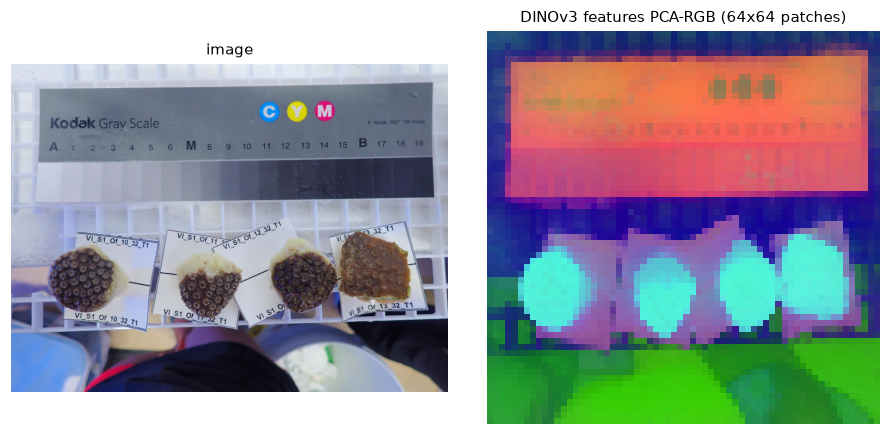

In [6]:
from sklearn.decomposition import PCA

feats = result.features                      # (Hp, Wp, D) on device
Hp, Wp = result.grid_hw
flat = feats.reshape(Hp * Wp, -1).cpu().numpy()
pca_rgb = PCA(3).fit_transform(flat).reshape(Hp, Wp, 3)
pca_rgb = (pca_rgb - pca_rgb.min()) / (np.ptp(pca_rgb) + 1e-8)

show(("image", image, {}),
     (f"DINOv3 features PCA-RGB ({Hp}x{Wp} patches)", pca_rgb, {}))

## 4 · Stage 2 — Semantic gate

Exemplar similarity decides *which patches are coral*, nothing about *which instance*. `prototype_map` is the smooth cosine-to-prototype; `score_map` is the positive-vs-negative margin; `foreground` is the gated class region that all later stages operate inside.

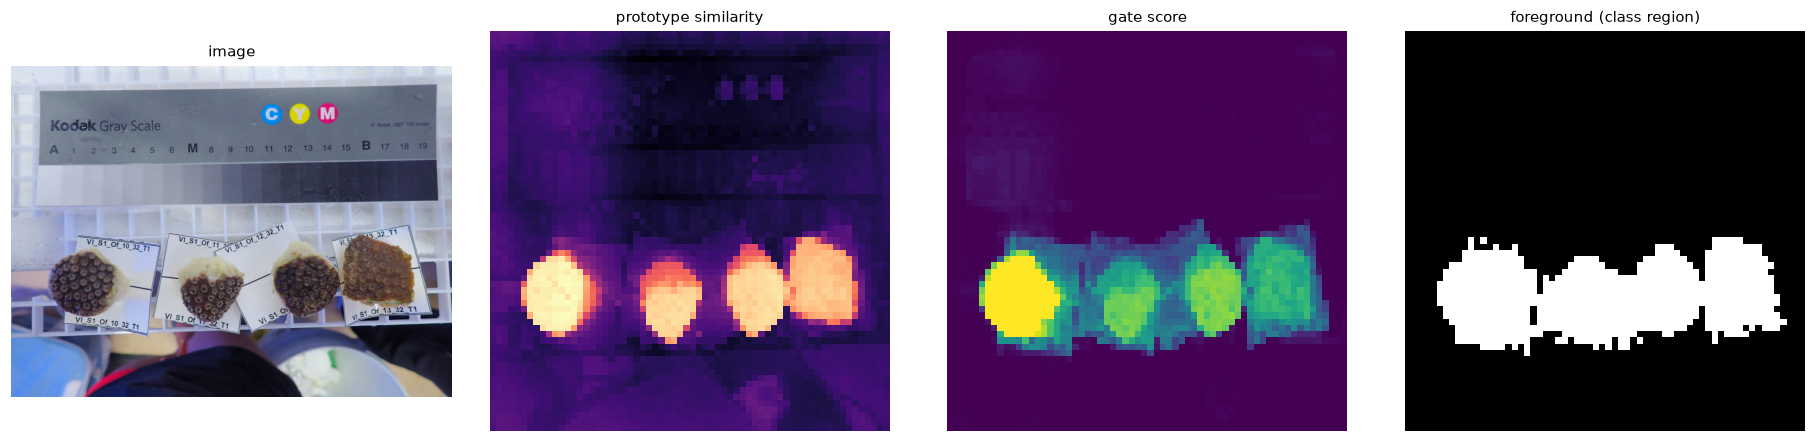

In [7]:
gate = result.gate   # GateResult
show(("image", image, {}),
     ("prototype similarity", gate.prototype_map, {"cmap": "magma"}),
     ("gate score", gate.score_map, {"cmap": "viridis"}),
     ("foreground (class region)", gate.foreground, {"cmap": "gray"}),
     cols=4)

## 5 · Stage 3 — Agglomerative over-segmentation

The foreground is split into many small **spatially-contiguous, feature-coherent atoms** (single threshold `cluster_tau`, no fixed K). These are the units the next stages group into instances.

n atoms: 88


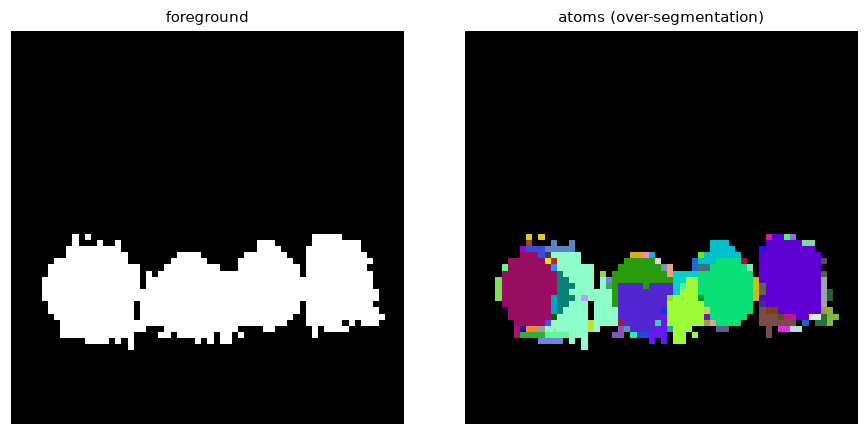

In [8]:
atoms = result.atom_labels
print("n atoms:", int(atoms.max()))
show(("foreground", result.gate.foreground, {"cmap": "gray"}),
     ("atoms (over-segmentation)", atoms, {"cmap": label_cmap(int(atoms.max())), "interpolation": "nearest"}))

## 6 · Stage 4 — Individuation (corrected watershed)

The **elevation** combines a *feature-boundary* cue (high where features change — seams between touching instances) and a *geometric* `1 - distance` cue (splits convex blobs). **Markers** (one per instance) seed the flood; the **mask** keeps it inside the class region. Contrast with the old model: no markers, no mask, wrong elevation.

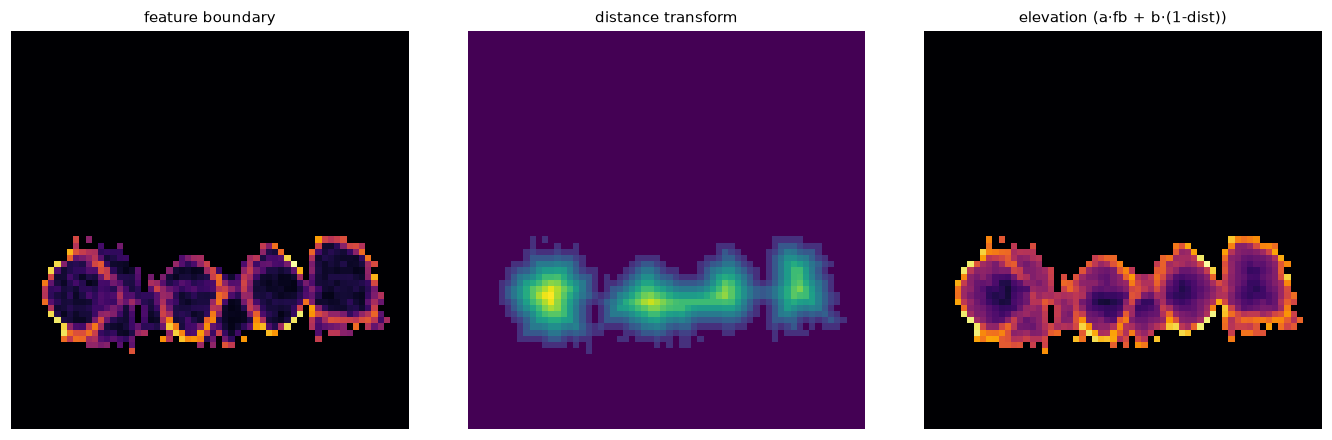

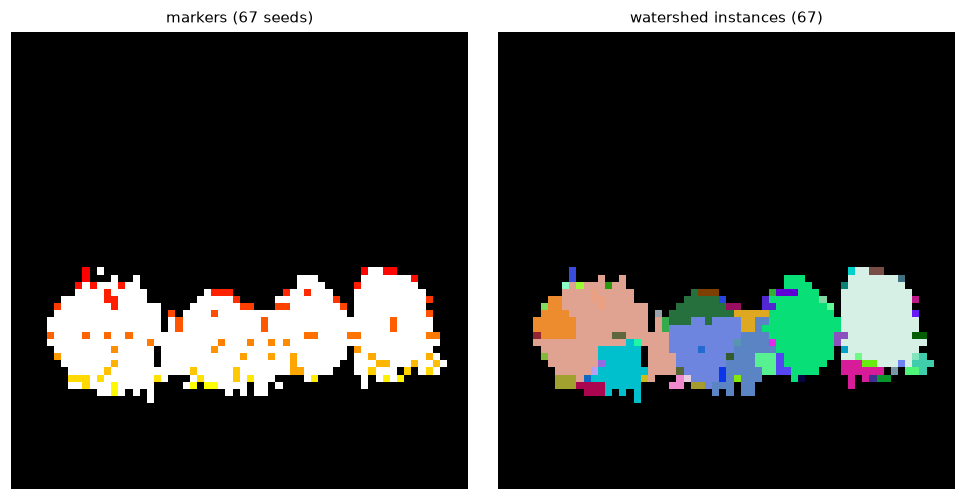

In [9]:
ind = result.individuation
show(("feature boundary", ind.feature_boundary, {"cmap": "inferno"}),
     ("distance transform", ind.distance, {"cmap": "viridis"}),
     ("elevation (a·fb + b·(1-dist))", ind.elevation, {"cmap": "inferno"}),
     cols=3)

markers_disp = np.ma.masked_where(ind.markers == 0, ind.markers)
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(result.gate.foreground, cmap="gray")
ax[0].imshow(markers_disp, cmap="autumn", interpolation="nearest")
ax[0].set_title(f"markers ({int(ind.markers.max())} seeds)", fontsize=10); ax[0].axis("off")
ax[1].imshow(ind.instances, cmap=label_cmap(int(ind.instances.max())), interpolation="nearest")
ax[1].set_title(f"watershed instances ({int(ind.instances.max())})", fontsize=10); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 7 · Stage 5 — Self-similarity merge

Watershed over-splits irregular fragments (several lobes → several labels). We merge adjacent regions whose prototypes are highly self-similar **and** whose shared border has a weak feature boundary (a real seam blocks the merge, keeping true instances apart).

67 watershed -> 8 after merge -> 8 final (filtered)


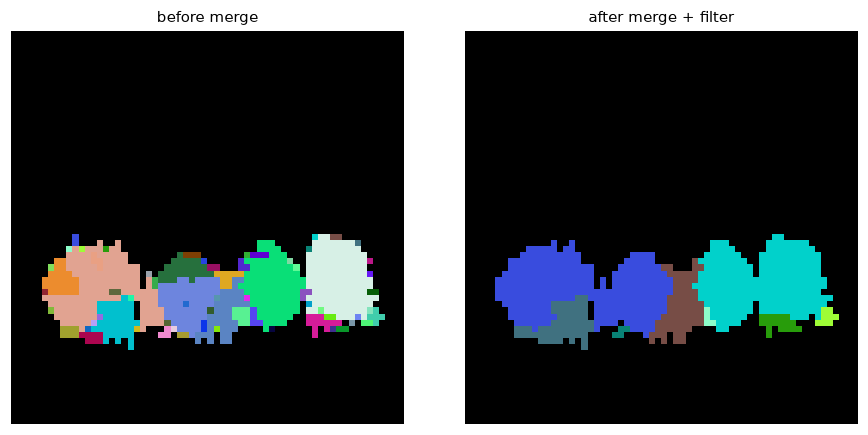

In [10]:
before = result.individuation.instances
after = result.merged_labels
print(f"{int(before.max())} watershed -> {int(after.max())} after merge -> {result.instance_masks.shape[0]} final (filtered)")
show(("before merge", before, {"cmap": label_cmap(int(before.max())), "interpolation": "nearest"}),
     ("after merge + filter", after, {"cmap": label_cmap(int(after.max())), "interpolation": "nearest"}))

## 8 · Final result — discovered instances

Full-resolution per-instance masks with per-instance gate scores, overlaid on the image.

8 instances  |  scores [0.753 0.672 0.41  0.635 0.465 0.379 0.405 0.428]


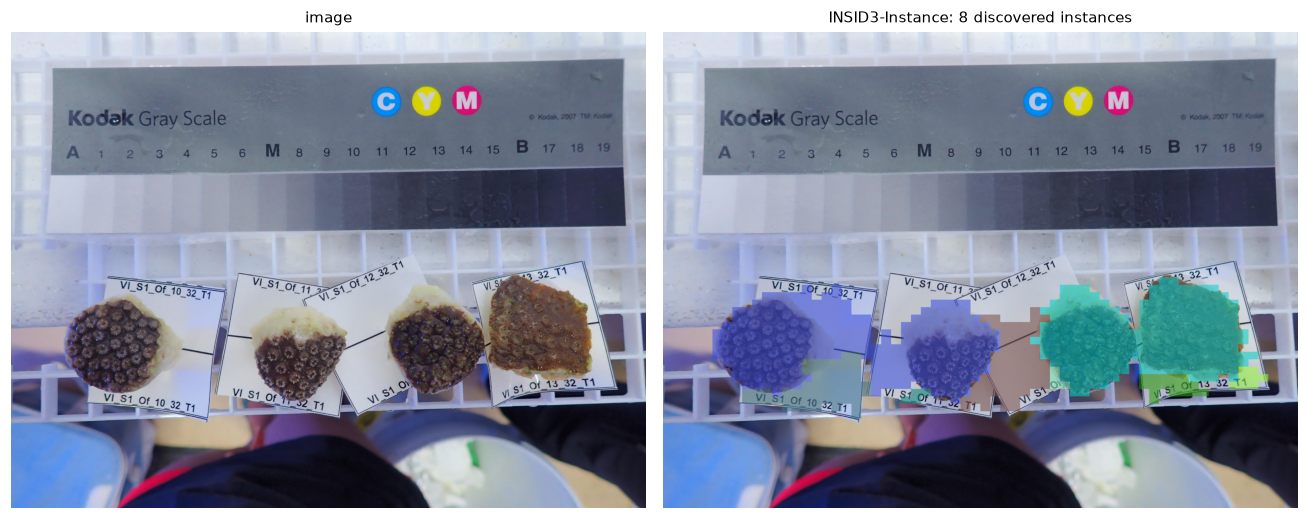

In [11]:
masks, scores = result.instance_masks, result.instance_scores
print(f"{len(masks)} instances  |  scores {np.round(scores,3) if len(scores) else '[]'}")

inst_label = np.zeros((H, W), np.int32)
for i, m in enumerate(masks, 1):
    inst_label[m > 0] = i

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(image); ax[0].set_title("image", fontsize=10); ax[0].axis("off")
ax[1].imshow(overlay_labels(image, inst_label)); ax[1].axis("off")
ax[1].set_title(f"INSID3-Instance: {len(masks)} discovered instances", fontsize=10)
plt.tight_layout(); plt.show()

## 9 · Tuning notes

| knob | effect |
|------|--------|
| `gate_threshold` ↑ | tighter class region (fewer false-positive patches) |
| `cluster_tau` ↑ | coarser atoms (fewer, larger) |
| `marker_mode` | `geometric` for convex/blobby, `feature` for irregular parts, `hybrid` for mixed |
| `elevation_beta` ↑ | stronger geometric splitting of touching convex instances |
| `merge_similarity` ↓ / `merge_boundary` ↑ | more aggressive merging (fewer instances) |
| backbone `image_size` ↑ | finer patch grid — needed for small/dense instances |

**Known ceiling:** two touching same-class instances with *no visual seam* cannot be split
by DINOv3 features alone; only the geometric term can separate them, and only when convex.
For those cases, seed these instance points into SAM (the service already hosts SAM3).